In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("/content/Advertising.csv")

In [4]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [22]:
df = df.rename(columns={df.columns[0]:"ID"})

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         200 non-null    int64  
 1   TV         200 non-null    float64
 2   Radio      200 non-null    float64
 3   Newspaper  200 non-null    float64
 4   Sales      200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [24]:
df.describe()

,ID,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [25]:
df.shape

(200, 5)

In [26]:
df.isnull().sum()

,0
ID,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [42]:
X = df.drop(columns = ['ID','Sales'],axis=1)
q_mean = X.mean()
total_mean = q_mean.mean()
Y = df['Sales']

In [43]:
X

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [44]:
q_mean

,0
TV,147.0425
Radio,23.2640
Newspaper,30.5540


In [45]:
q_mean = q_mean.to_frame(name='mean')
q_mean = q_mean.reset_index()

In [46]:
q_mean

,index,mean
0,TV,147.0425
1,Radio,23.2640
2,Newspaper,30.5540


<Axes: xlabel='index', ylabel='Sales'>

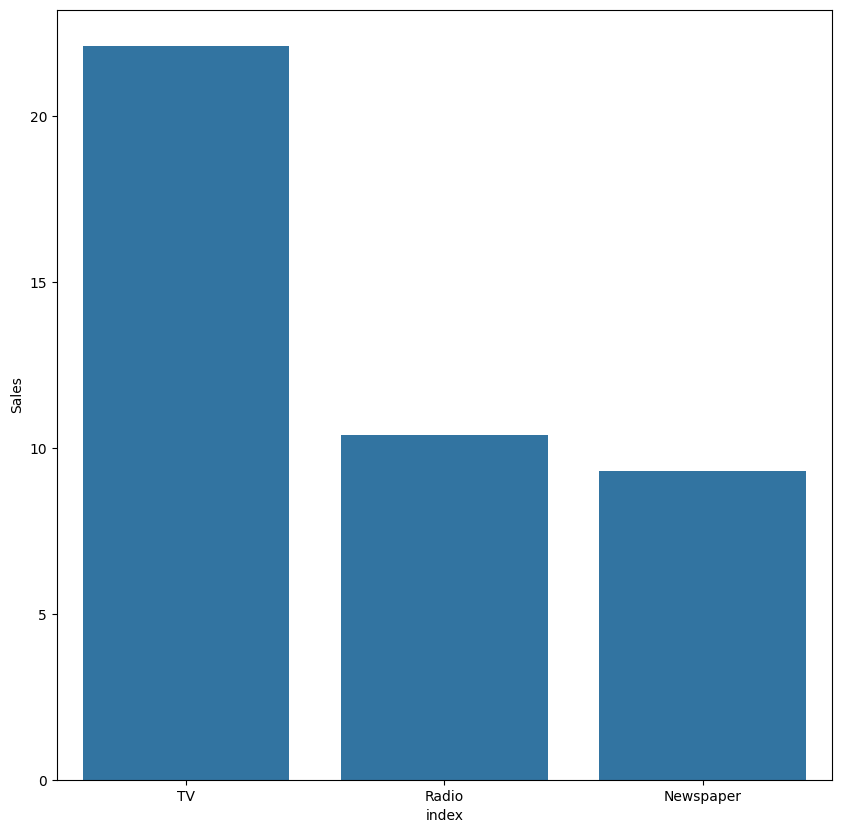

In [47]:
plt.figure(figsize=(10,10))
sns.barplot(x='index',y=Y,data=q_mean)

In [48]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [49]:
model = LinearRegression()

In [53]:
model.fit(X_train,Y_train)

LinearRegression()

In [54]:
y_pred = model.predict(X_test)

In [55]:
r2 = r2_score(Y_test,y_pred)
mse = mean_squared_error(Y_test,y_pred)

In [56]:
r2

0.899438024100912

In [57]:
mse

3.174097353976104

In [58]:
input = [[230.1,37.8,69.2]]

In [59]:
new_sales = model.predict(input)

In [60]:
print("New_Sales_Prediction:",new_sales)

New_Sales_Prediction: [20.61397147]


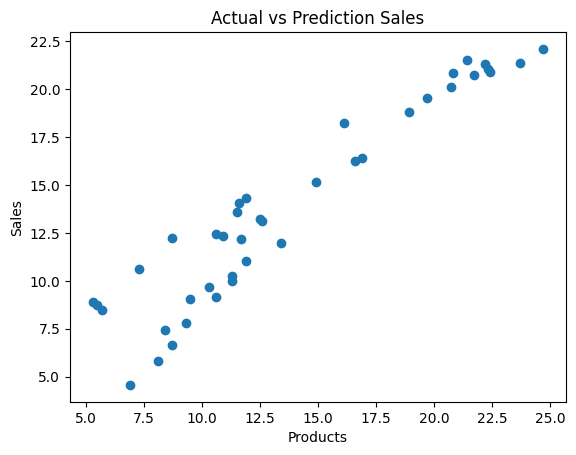

In [61]:
plt.scatter(Y_test,y_pred)
plt.xlabel("Products")
plt.ylabel("Sales")
plt.title("Actual vs Prediction Sales")
plt.show()